#**The Frequency of Earthquakes and Magnitude**
CMSC320 Summer 2026 Data Science Project

Collaborators:

*   Anuja Annavarapu (A,C,D,E,F,G) Worked on null hypothesis with ANOVA test, and the ML algorithms with implementing ploynomial features.

*   Natalie Figueira (A,B,C,D,E,G) Helped with processing the earthquake data like dropping some of the columns, adding a clear datetime format of date for data exploration and with the helped development of ML algorithms.

*   Ana Lungu (A,C,D,E,F,G) Helped with data exploration and ML Algorithm as well as the visualization of the data exploration analysis.

#**Introduction**

For this project, we wanted to look at earthquakes. Over time, it often feels like earthquakes have been getting more frequent. We wanted to explore how earthquake frequency and other characteristics, such as depth and magnitude, vary across the Northern Hemisphere over time. We also wanted to see whether, by looking at features such as depth, latitude, longitude, and year, we could predict an earthquake's magnitude. We also wanted to see if an ML model could predict the frequency of earthquakes. It could help identify where earthquakes are more common or larger and see whether these factors are meaningful for an earthquake's magnitude.

<br><br>

But before we can move into that we need to get our imports ready and explain the data we are using.

In [1]:
#imports
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#ML imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures


# **DATA PROCESSING**


We are using Earthquake data from the USGS earthquake data website  [USGS Earthquake Database](https://earthquake.usgs.gov/earthquakes/search/).  

We downloaded a .CSV file that contains data is from June 1st, 2005 to September 27th, 2012. It includes earthquake data that has been reviewed.  

Dataset citation:
USGS. (2019). Search Earthquake Catalog. Usgs.Gov. https://earthquake.usgs.gov/earthquakes/search/

In [2]:
earthquakes_df = pd.read_csv("Earthquakes.csv")
earthquakes_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2005-06-01T12:24:21.490Z,18.4620,-68.7530,148.1,4.2,mb,47.0,47.7,NaN,NaN,...,2014-11-07T01:26:03.100Z,"9 km WNW of San Rafael del Yuma, Dominican Rep...",earthquake,NaN,NaN,NaN,11.0,reviewed,rspr,us
1,2005-06-01T21:55:04.580Z,17.0910,-46.4740,10.0,5.0,mwc,241.0,44.7,NaN,0.72,...,2025-12-19T23:08:34.930Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2005-06-01T21:58:40.450Z,17.0670,-46.4480,10.0,4.8,mb,81.0,46.4,NaN,0.69,...,2014-11-07T01:26:04.203Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,30.0,reviewed,us,us
3,2005-06-02T04:50:07.800Z,19.4800,-103.5720,7.0,4.1,md,6.0,104.8,NaN,NaN,...,2014-11-07T01:26:04.430Z,"5 km NNW of Cofradía, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,unm,unm
4,2005-06-02T09:29:38.580Z,26.4510,-44.7070,10.0,4.7,mb,21.0,128.4,NaN,1.16,...,2014-11-07T01:26:04.558Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,12.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2012-09-26T11:37:27.550Z,10.2180,-85.1100,57.1,4.2,mb,31.0,196.4,NaN,0.86,...,2014-11-07T01:48:55.204Z,"17 km WSW of Juntas, Costa Rica",earthquake,NaN,5.3,NaN,13.0,reviewed,us,us
15996,2012-09-26T18:15:22.200Z,14.8520,-61.2440,169.6,4.3,md,32.0,136.9,NaN,NaN,...,2014-11-07T01:48:55.280Z,"13 km W of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,trn,trn
15997,2012-09-26T22:23:23.940Z,26.8630,-44.2400,10.0,4.4,mb,40.0,88.6,NaN,1.04,...,2014-11-07T01:48:55.300Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,10.0,reviewed,us,us
15998,2012-09-27T03:03:41.090Z,9.8210,-85.5690,36.7,4.4,mb,60.0,139.7,NaN,1.36,...,2014-11-07T01:48:55.505Z,"8 km SW of Sámara, Costa Rica",earthquake,NaN,9.5,NaN,32.0,reviewed,us,us


We first find some information about the dataset before any modifications take place. Below shows how many entries are there. We are examining 16,000 earthquakes.

We have 22 columns that represent different types of data such as latitude, longitude, depth, magnitude, error margins, date, place, and much more.

In [3]:
print(f"df.shape: {earthquakes_df.shape}")
earthquakes_df.shape
print("df.describe(): ")
display(earthquakes_df.describe())
print("df.info(): ")
earthquakes_df.info()


df.shape: (16000, 22)
df.describe(): 


,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,16000.000000,16000.000000,16000.000000,16000.00000,14720.000000,14717.000000,1490.000000,7664.000000,1513.000000,4770.000000,1176.000000,6173.000000
mean,27.611573,-104.703152,38.187911,4.10787,47.583628,168.173160,0.278961,0.850562,1.483323,14.140468,0.191622,51.673092
std,16.763399,31.873068,43.143381,0.49540,77.578092,79.883874,0.357982,0.889954,5.029209,155.091728,0.157575,84.415456
min,7.959000,-171.562000,-2.285000,3.50000,0.000000,11.900000,0.001802,0.009800,0.080000,0.000000,0.000000,0.000000
25%,15.886000,-120.798542,10.000000,3.70000,8.000000,107.000000,0.054320,0.570000,0.300000,0.500000,0.134000,5.000000
50%,18.629000,-98.362000,19.000000,4.00000,18.000000,170.200000,0.166600,0.920000,0.580000,4.025000,0.163000,15.000000
75%,40.308958,-87.848000,51.700000,4.40000,49.000000,219.800000,0.392775,1.150000,1.630000,12.000000,0.200000,50.000000
max,72.852000,-36.609000,294.900000,7.60000,857.000000,358.300000,5.654000,69.320000,99.000000,9117.600000,1.680000,438.000000


df.info(): 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             16000 non-null  object 
 1   latitude         16000 non-null  float64
 2   longitude        16000 non-null  float64
 3   depth            16000 non-null  float64
 4   mag              16000 non-null  float64
 5   magType          16000 non-null  object 
 6   nst              14720 non-null  float64
 7   gap              14717 non-null  float64
 8   dmin             1490 non-null   float64
 9   rms              7664 non-null   float64
 10  net              16000 non-null  object 
 11  id               16000 non-null  object 
 12  updated          16000 non-null  object 
 13  place            16000 non-null  object 
 14  type             16000 non-null  object 
 15  horizontalError  1513 non-null   float64
 16  depthError       4770 non-null   float64
 17  

It's currently sorted by date but we want to sort it by magnitude so we can see what was the biggest earthquakes in our data set:

Parse data: Sort by magnitude

In [4]:
#sort by mag highest to smallest
earthquakes_df = earthquakes_df.sort_values(by=['mag'], ascending=False).reset_index(drop='True')

#this line below is to check if there was mag error, there is, maybe we could use it
earthquakes_df = earthquakes_df.drop(columns=['magError', "depthError", "horizontalError", "status", "type"])
earthquakes_df = earthquakes_df.dropna(subset=['gap'])
#date only column, in datetime (remove .dt.date to get full date and time in datetime format)
date = pd.to_datetime(earthquakes_df['time']).dt.date
earthquakes_df.insert(0, 'date', date)
earthquakes_df = earthquakes_df[earthquakes_df["locationSource"] == earthquakes_df["magSource"]]
display(earthquakes_df)

,date,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,magNst,locationSource,magSource
0,2012-09-05,2012-09-05T14:42:07.800Z,10.085000,-85.315000,35.000,7.6,mww,703.0,34.3,NaN,1.20,us,usp000jrsw,2025-01-03T07:43:01.170Z,"11 km ENE of Hojancha, Costa Rica",NaN,us,us
1,2007-11-29,2007-11-29T19:00:20.420Z,14.944000,-61.274000,156.000,7.4,mwb,663.0,13.4,NaN,0.74,us,usp000ftj1,2022-07-13T02:37:48.411Z,"18 km WNW of Basse-Pointe, Martinique",NaN,us,us
2,2012-03-20,2012-03-20T18:02:47.440Z,16.493000,-98.231000,20.000,7.4,mww,672.0,37.9,NaN,0.98,us,usp000jghj,2022-05-03T15:34:09.063Z,"6 km E of Santiago Llano Grande, Mexico",NaN,us,us
3,2012-08-27,2012-08-27T04:37:19.430Z,12.139000,-88.590000,28.000,7.3,mww,417.0,37.0,NaN,1.30,us,usp000jqvm,2022-05-03T15:48:15.643Z,"126 km S of Puerto El Triunfo, El Salvador",NaN,us,us
5,2010-04-04,2010-04-04T22:40:42.360Z,32.286167,-115.295333,9.987,7.2,mw,10.0,239.0,0.5137,0.11,ci,ci14607652,2026-05-26T02:57:40.282Z,"The 2010 Sierra El Mayor, B.C., Mexico Earthquake",0.0,ci,ci
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15994,2009-05-25,2009-05-25T10:18:49.230Z,19.240000,-64.874000,25.200,3.5,md,6.0,299.2,NaN,NaN,us,usp000gxgv,2014-11-07T01:39:01.005Z,"99 km N of Charlotte Amalie, U.S. Virgin Islands",NaN,rspr,rspr
15995,2007-10-01,2007-10-01T10:24:44.890Z,43.374000,-126.586000,10.000,3.5,ml,36.0,207.1,NaN,0.79,us,usp000fpmb,2014-11-07T01:33:46.672Z,"179 km W of Bandon, Oregon",NaN,us,us
15996,2006-03-07,2006-03-07T07:39:48.790Z,19.118000,-63.884000,5.000,3.5,md,8.0,317.1,NaN,NaN,us,usp000ebkv,2014-11-07T01:28:29.244Z,"129 km NE of Cruz Bay, U.S. Virgin Islands",NaN,rspr,rspr
15998,2009-05-28,2009-05-28T12:39:49.210Z,54.014000,-164.487000,55.800,3.5,ml,26.0,196.1,NaN,NaN,us,usp000gxkw,2019-02-13T11:58:01.342Z,"85 km E of Akutan, Alaska",NaN,aeic,aeic


We removed earthquakes with missing gap values because gap is an important measure of the quality of an earthquake's recorded location and we only want to study earthquakes with that measure recorded. 

We dropped certain columns: <br>
-The errors magError, depthError, horizontalError because they were mostly null and mostly irrelevant to our analysis<br>
-Status because all entries were  reviewed<br>
-Type because all entries were earthquakes<br>

#**Exploratory Data Analysis**

Now that our data has been processed, we need to see if there are any trends in our earthquake data. We used the Chi-Square Test to look at the frequency of earthquakes based on the regions they took place in, used ANOVA testing to compare earthquake characteristics in certain latitude regions, and used Pearson Correlation to see if magnitude and depth had a strong relationship, which could help us when it comes to ML testing later.  

<br>

### Method 1: Frequency of Earthquakes Based on Geographical Region using Chi Square Test


We will first examine the frequency of earthquakes based off of geographical region. To better visualize the correlation between how often the earthquakes happen and which locations get the most number of earthquakes, we will use a bar chart and a pie chart. First, we want to see how frequent are the earthquakes in the locations in our database. We notice that most of the locations have only 1 earthquake, with the graph being extremely right skewed that is almost imposible to be seen on the graph. From this first graph we understand that most of the locations in our data base have less than 10 earthquakes.

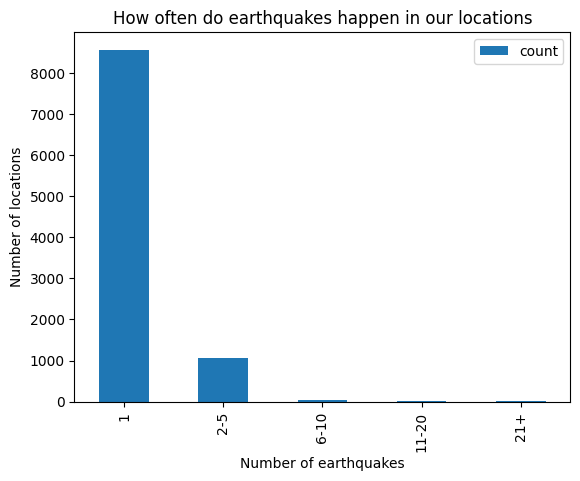

In [5]:
place_types = earthquakes_df['place'].value_counts()
#print(place_types.count())

bins = [0,1, 5, 10, 20, float('inf')]
labels = ['1','2-5','6-10', '11-20', '21+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()

binned_occurences.plot(kind='bar')
plt.title('How often do earthquakes happen in our locations')
plt.xlabel('Number of earthquakes')
plt.ylabel('Number of locations')
plt.legend()

plt.show()

There is a lot of locations that only experience one earthquake. We wanted to see exactly which locations are prone to having more earthquakes and their exact number of earthquakes. More specifically, we wanted to take a closer look at the locations that have more than 10 earthquakes.

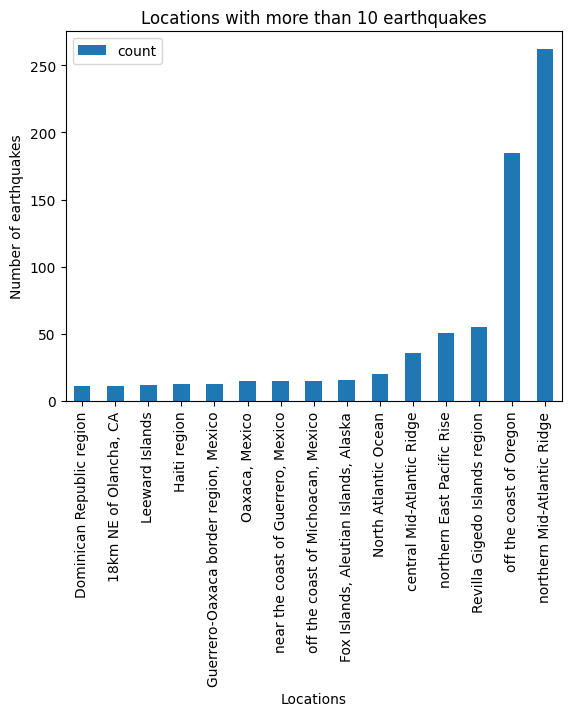

In [6]:
place_types_more_than_10_occurences = place_types[place_types > 10]

place_types_more_than_10_occurences.sort_values().plot(kind='bar')

plt.title("Locations with more than 10 earthquakes")
plt.ylabel('Number of earthquakes')
plt.xlabel('Locations')
plt.legend()
plt.show()

Notice that there are 2 locations with an astonishing amount of earthquakes, more than 100. These 2 locations are the outliers that are skewing the graph. This made us wonder what is the distribution of the frequency of earthquakes.
<br>
<br>

---
---
---

<br>
Among our dataset, we wondered what is the percentage of locations that suffered 1 earthquake, between 2 and 10, and finally, more than 11. For this question we used the pie chart which perfectly shows that almost 88% of the locations have suffered only 1 earthquake, while 0.174% have suffered more than 11 earthquakes.

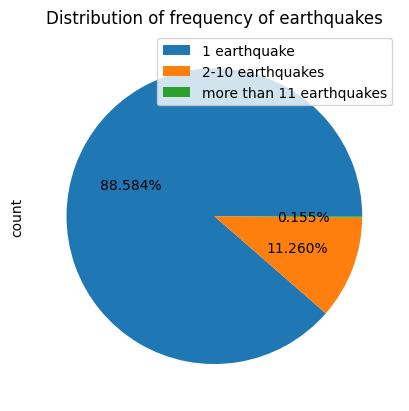

In [7]:
bins = [0,1, 10, float('inf')]
labels = ['1','2-10', '11+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()


legend=['1 earthquake', '2-10 earthquakes', 'more than 11 earthquakes']
myexplode=[0, 0, 0.7]
binned_occurences.plot(kind='pie', labels=None, autopct='%1.3f%%')
plt.title('Distribution of frequency of earthquakes')
plt.legend(legend)
plt.show()

This brought us to our next question, are certain areas more prone to earthquakes with higher or lower frequency?
<br>
<br>
We want to see the relationship and the ratio between the frequency of the earthquakes and the areas where these earthquakes happened. We will be using the Chi-Square Test for Independence and our Null Hypothesis is that there is no relation.

In [8]:
#place_types = earthquakes_df['place'].value_counts()

my_places = place_types

my_places = my_places.reset_index()
my_places.columns = ['place', 'count']

#calculate the average latitude for each place
latitude_table = earthquakes_df.groupby('place', as_index=False)['latitude'].mean()

earthquake_dataframe = pd.merge(
    my_places,
    latitude_table,
    on='place',
    how='inner'
)

#this is variable 1
bins = [0, 1, 10, float('inf')]
labels = ['1 earthquake', '2 to 10 earthquakes', 'more than 10 earthquakes']
earthquake_dataframe['count category'] = pd.cut(earthquake_dataframe['count'], bins = bins, labels=labels)

#this is variable 2
bins = [0, 30, 60, 90]
labels = ['Low Latitude', 'Mid Latitude', 'High Latitude']
earthquake_dataframe['region category'] = pd.cut(earthquake_dataframe['latitude'], bins = bins, labels=labels)


#i need contingency table
contingency_table = pd.crosstab(earthquake_dataframe['count category'], earthquake_dataframe['region category'])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(contingency_table)

print("\np-value:", p_value)

if p_value <= 0.05:
    print('\nDependent (reject H0)')
else:
    print('\nIndependent (H0 holds true)')

region category           Low Latitude  Mid Latitude  High Latitude
count category                                                     
1 earthquake                      6632          1837             98
2 to 10 earthquakes                652           431              6
more than 10 earthquakes            12             3              0

p-value: 1.8499293547862724e-37

Dependent (reject H0)


The Chi-square test shows that there is a relation between the lower, middle, higher part of the locations in our dataframe, and the earthquake frequency. From the table we can see that locations with only one earthquake are predominantly in the lower region, and the earthquakes are not evenly distributed across lower, middle and higher regions.

### Method 2: Comparison of Earthquake Characteristics Across Latitude Regions using ANOVA testing

We have three divides of the Northen Hemisphere: **Low Latitude, Mid Latitude, and High Latitude**
<br><br>
Having examined how earthquake frequency varies across latitude regions, we now investigate whether the characteristics of the earthquake events themselves (depth and magnitude) also differ across those regions. Earlier we observed that the Low Latitude region contains the largest number of earthquake locations across all frequency categories, followed by the Mid Latitude region, while the High Latitude region has the fewest. Let's perform Anova to examine the average depths across the different regions:

In [9]:
#divide the dataframe into the regions
groups = earthquake_dataframe.groupby("region category",observed=False)

low = groups.get_group("Low Latitude")
mid = groups.get_group("Mid Latitude")
high = groups.get_group("High Latitude")

#grab the places within each region from the original dataframe
low_places = low["place"]
low_earthquakes = earthquakes_df[earthquakes_df["place"].isin(low_places)]

mid_places = mid["place"]
mid_earthquakes = earthquakes_df[earthquakes_df["place"].isin(mid_places)]

high_places = high["place"]
high_earthquakes = earthquakes_df[earthquakes_df["place"].isin(high_places)]

#print the avg depths
print("Mean depth of lower lat regions:",low_earthquakes['depth'].mean())
print("Mean depth of middle lat regions:", mid_earthquakes['depth'].mean())
print("Mean depth of higher lat regions:", high_earthquakes['depth'].mean())

#perform the ANOVA test
f_stat, p_value = stats.f_oneway(low_earthquakes["depth"].dropna(), mid_earthquakes["depth"].dropna(), high_earthquakes["depth"].dropna())
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value <= 0.05:
    print("Reject H0: at least one region has a significantly different mean depth.")
else:
    print("Fail to reject H0: no significant difference in mean depth across regions.")

Mean depth of lower lat regions: 46.75337933808319
Mean depth of middle lat regions: 14.929933457711442
Mean depth of higher lat regions: 9.923931623931622
F-statistic: 745.9456254880679
p-value: 4.024379451171668e-306
Reject H0: at least one region has a significantly different mean depth.


We see that between the three regions, there is at least one region with a significantly different mean depth. Let's dig down further and see exactly which region is significantly different using Tukey's HSD test:

In [10]:
#because depth and region category are from two different dataframes, we merge them by stacking each column
tukey_df = pd.DataFrame({
    "depth": pd.concat([low_earthquakes["depth"],mid_earthquakes["depth"],high_earthquakes["depth"]], ignore_index=True),
    "region category": (["Low Latitude"] * len(low_earthquakes) + ["Mid Latitude"] * len(mid_earthquakes) + ["High Latitude"] * len(high_earthquakes))
})

tukey = pairwise_tukeyhsd(endog=tukey_df["depth"], groups=tukey_df["region category"], alpha=0.05)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1       group2    meandiff p-adj   lower    upper  reject
------------------------------------------------------------------
High Latitude Low Latitude  36.8294    0.0   27.952 45.7069   True
High Latitude Mid Latitude    5.006 0.3912  -3.9713 13.9833  False
 Low Latitude Mid Latitude -31.8234    0.0 -33.7918 -29.855   True
------------------------------------------------------------------


Here we can see that all three regions have significally different mean depths from the others. This suggests a strong relationship between latitude region and earthquake depth.

Let's plot the data to observe other statistical characteristics:

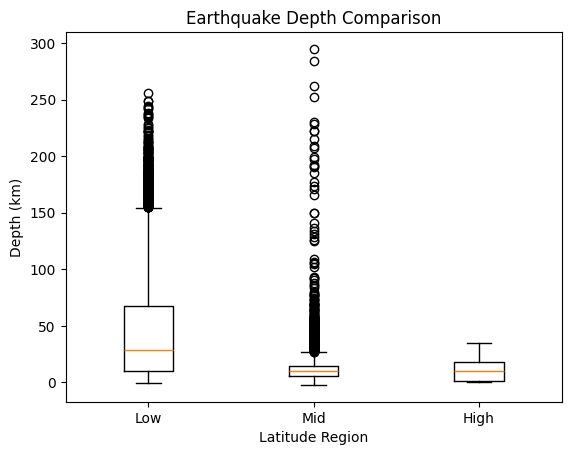

In [11]:
data = [
    low_earthquakes["depth"],
    mid_earthquakes["depth"],
    high_earthquakes["depth"]
]

plt.boxplot(data, tick_labels=["Low", "Mid", "High"])
plt.title("Earthquake Depth Comparison")
plt.xlabel("Latitude Region")
plt.ylabel("Depth (km)")
plt.show()

The box plot shows that the three latitude regions have different distributions of earthquake depths. The Low Latitude region has the highest median depth, the Mid Latitude region has the lowest median depth, and the High Latitude region is in between those two. These visual differences are consistent with our ANOVA and Tukey HSD results. One thing to note is that there are so many outliers for the earthquake depth.

Now let's do the same analysis for magnitude:

In [12]:
#print the avg mags
print("Mean magnitude of lower lat regions:",low_earthquakes['mag'].mean())
print("Mean magnitude of middle lat regions:", mid_earthquakes['mag'].mean())
print("Mean magnitude of higher lat regions:", high_earthquakes['mag'].mean())

#perform the ANOVA test
f_stat, p_value = stats.f_oneway(low_earthquakes["mag"].dropna(), mid_earthquakes["mag"].dropna(), high_earthquakes["mag"].dropna())
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value <= 0.05:
    print("Reject H0: at least one region has a significantly different mean magnitude.")
else:
    print("Fail to reject H0: no significant difference in mean magnitude across regions.")

Mean magnitude of lower lat regions: 4.06151574350724
Mean magnitude of middle lat regions: 3.9356996268656714
Mean magnitude of higher lat regions: 4.077777777777778
F-statistic: 103.64821743567079
p-value: 2.341641702026219e-45
Reject H0: at least one region has a significantly different mean magnitude.


Here we see that at least one region has a significantly different mean magnitude. Let's dig down even further and perform Tukey's HSD test for this result as well:

In [13]:
#because mag and region category are from two different dataframes, we merge our two necessary columns by stacking each column
tukey_df = pd.DataFrame({
    "mag": pd.concat([low_earthquakes["mag"],mid_earthquakes["mag"],high_earthquakes["mag"]], ignore_index=True),
    "region category": (["Low Latitude"] * len(low_earthquakes) + ["Mid Latitude"] * len(mid_earthquakes) + ["High Latitude"] * len(high_earthquakes))
})

tukey = pairwise_tukeyhsd(endog=tukey_df["mag"], groups=tukey_df["region category"], alpha=0.05)

print(tukey)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
    group1       group2    meandiff p-adj   lower   upper  reject
-----------------------------------------------------------------
High Latitude Low Latitude  -0.0163 0.9111  -0.109  0.0765  False
High Latitude Mid Latitude  -0.1421 0.0011 -0.2359 -0.0483   True
 Low Latitude Mid Latitude  -0.1258    0.0 -0.1464 -0.1053   True
-----------------------------------------------------------------


Here we can see that all three regions have significantly different mean magnitudes from one another. This indicates that earthquake magnitude varies significantly across latitude regions, which is the same conclusion we derived for the earthquake depth.

Let's plot for magnitude:

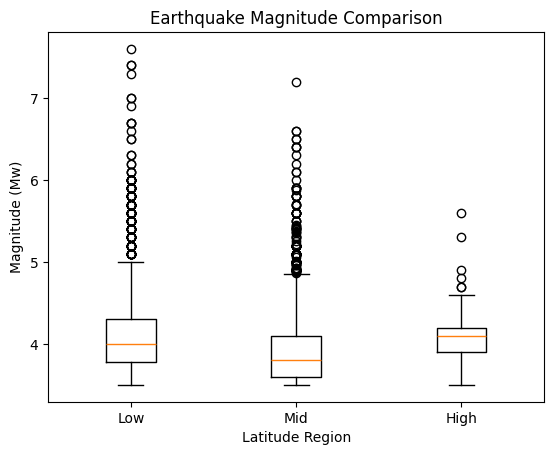

In [14]:
data = [
    low_earthquakes["mag"],
    mid_earthquakes["mag"],
    high_earthquakes["mag"]
]

plt.boxplot(data, tick_labels=["Low", "Mid", "High"])
plt.title("Earthquake Magnitude Comparison")
plt.xlabel("Latitude Region")
plt.ylabel("Magnitude (Mw)")
plt.show()

Here we see that the Low Latitude region has the highest median earthquake magnitude, while the Mid Latitude and High Latitude regions have slightly lower and more similar medians. This is still consistent with the Anova and Tukey HSD test results. Notice that there are fewer outliers in the magnitude data as well.

### Method 3: Magnitude vs Depth using Pearson Correlation

Earlier, we found that the Low Latitude region has the highest earthquake frequency, as well as the highest average magnitude and depth. Now, we focus on this region to investigate whether earthquake magnitude and depth are correlated.

Pearson correlation (Magnitude vs. Depth): -0.046476072683721774


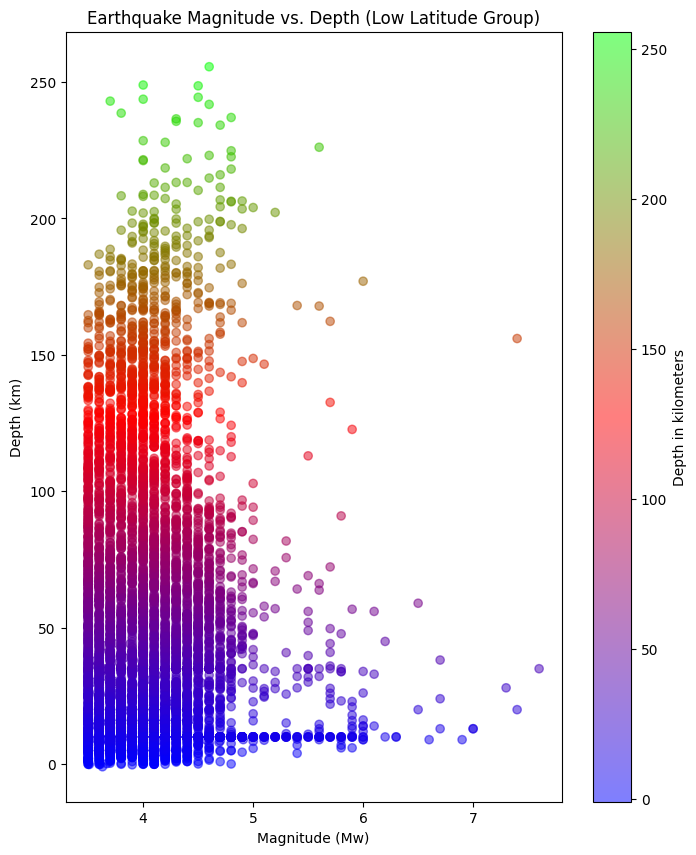

In [15]:
south_locations = earthquake_dataframe[earthquake_dataframe['region category'] == 'Low Latitude']['place']
region = earthquakes_df[earthquakes_df['place'].isin(south_locations)].copy()

rvalue = region['mag'].corr(region['depth'])
print(f"Pearson correlation (Magnitude vs. Depth): {rvalue}")
region['date'] = pd.to_datetime(region['date'])

plt.figure(figsize=(8, 10))
#use colors to help show the differences in depth used 0.5 alpha so the colors show better
plt.scatter(region['mag'], region['depth'], c=region['depth'], cmap='brg', alpha=0.5)
plt.colorbar(label="Depth in kilometers")

plt.title("Earthquake Magnitude vs. Depth (Low Latitude Group)")
plt.xlabel("Magnitude (Mw)")
plt.ylabel("Depth (km)")
plt.show()

Now, looking at the data below can feel super overwhelming, but that's because there were a lot of earthquakes in a Low Latitude region, as mentioned before. Looking at the graph, it can be said that after a magnitude of 5.5, the depth of an earthquake is likely to be smaller than 175km.

There is a weak negative correlation, but because there is so much data, we need to break some of it down. We are going to still look at the south group. But we are going to visualize how many earthquakes there are by date.

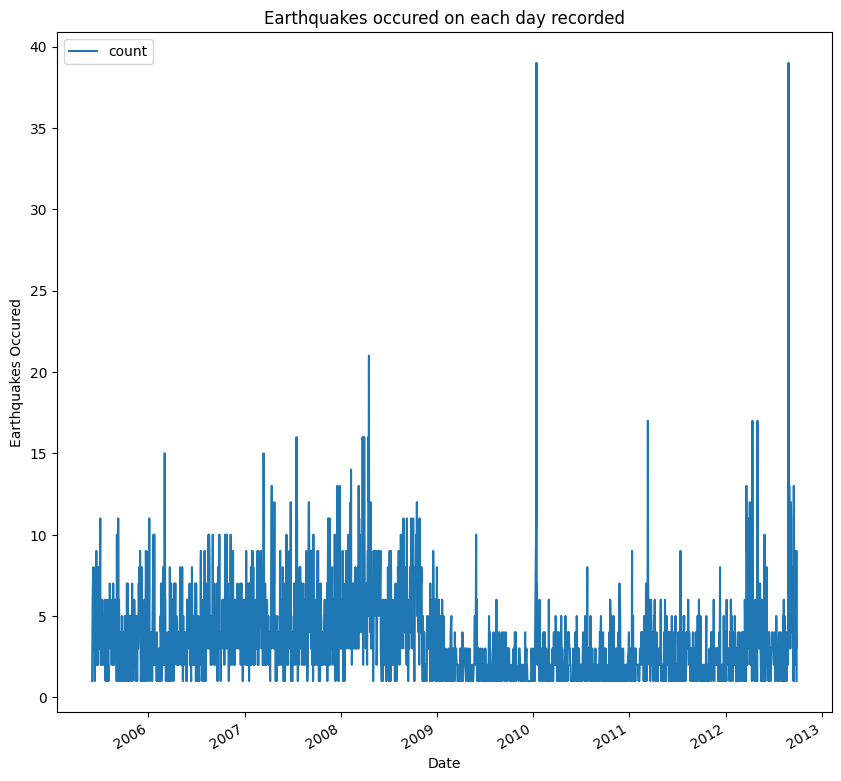

In [16]:
plt.figure(figsize=(10, 10))
region['date'].value_counts().sort_index().plot()
plt.xlabel("Date")
plt.ylabel("Earthquakes Occured")
plt.legend()
plt.title("Earthquakes occured on each day recorded")
plt.show()

We can see huge spikes in earthquakes around 2008, 2010, 2011, and 2012. But we are going to break this down a little further to examine the correlation between Depth and Magnitude across all years. Then we can see whether the years with a big spike in earthquakes (2008, 2010, 2011, and 2012) show a stronger correlation.

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2005 for depth and mag is: 0.013913449777748492


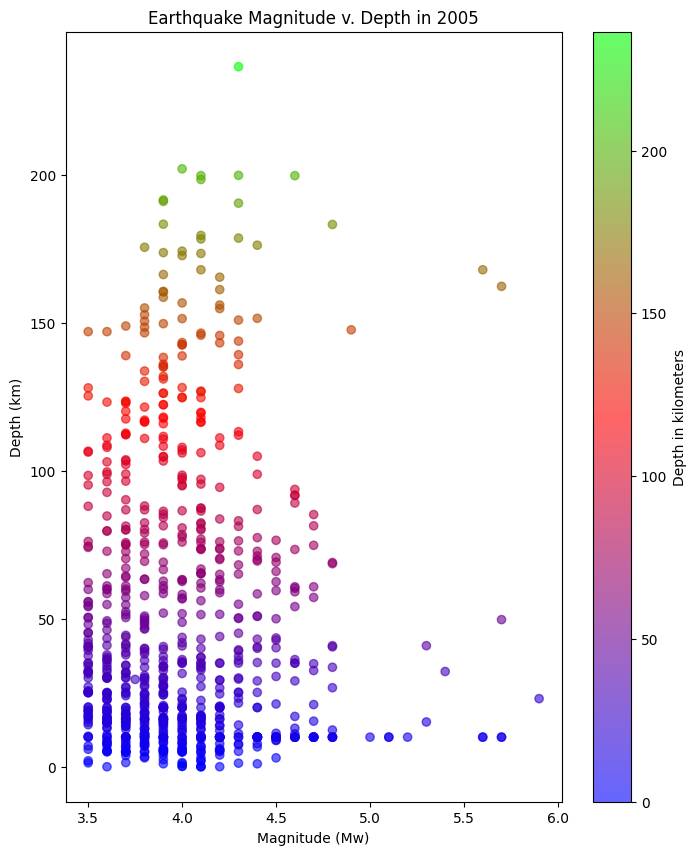

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2006 for depth and mag is: -0.06879542216087715


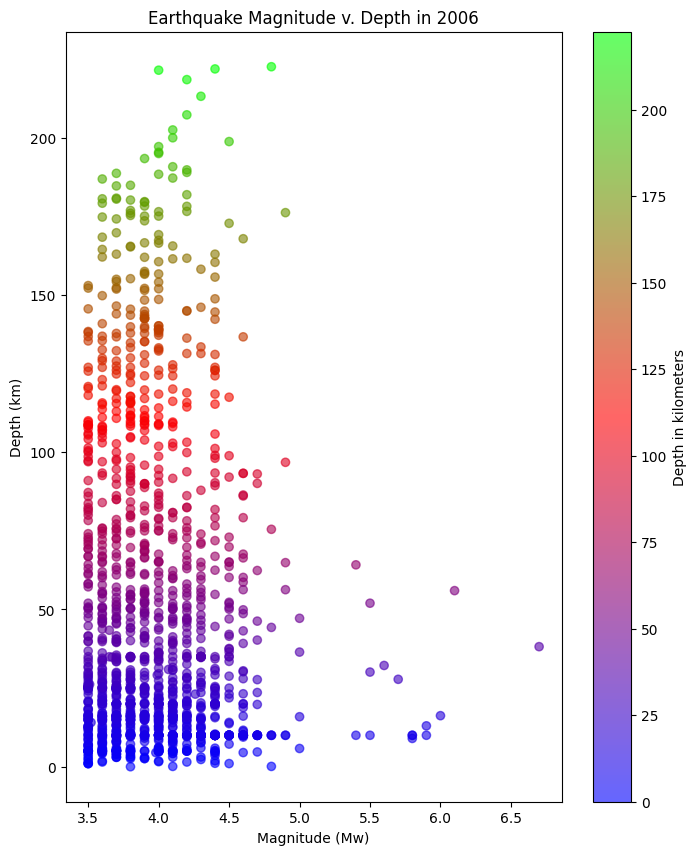

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2007 for depth and mag is: 0.02087934170241568


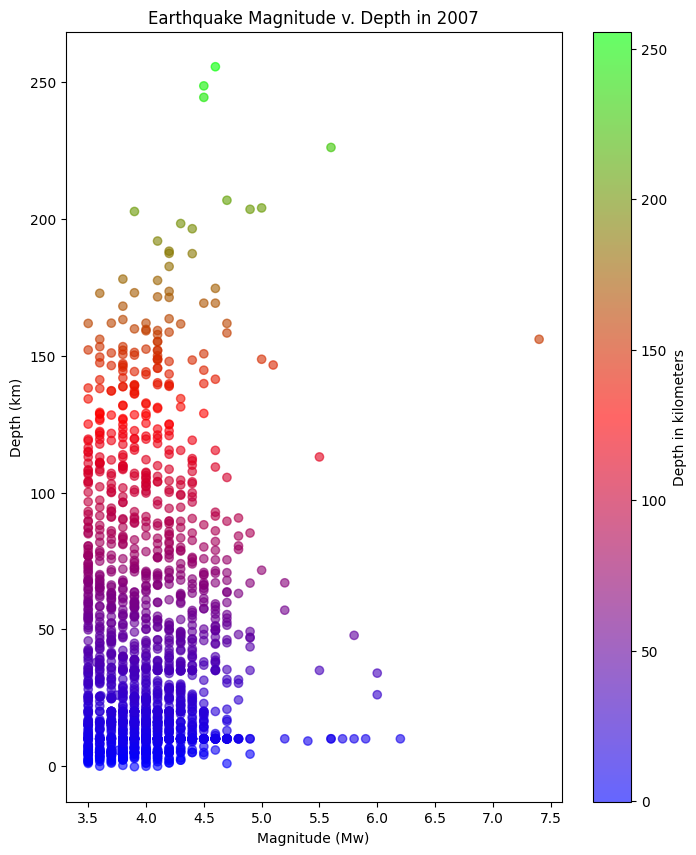

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2008 for depth and mag is: 0.0027921241412585487


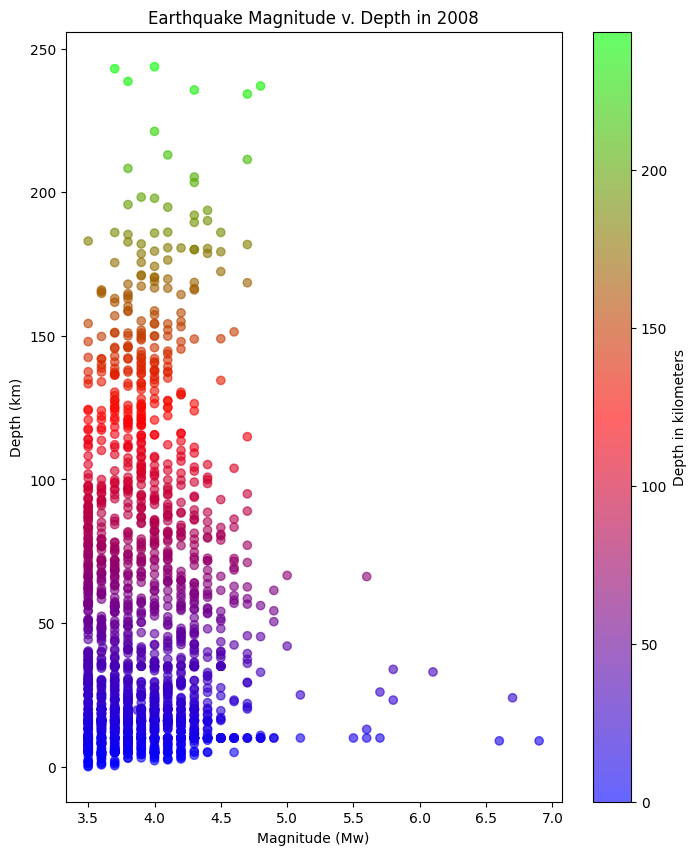

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2009 for depth and mag is: -0.1104486940893666


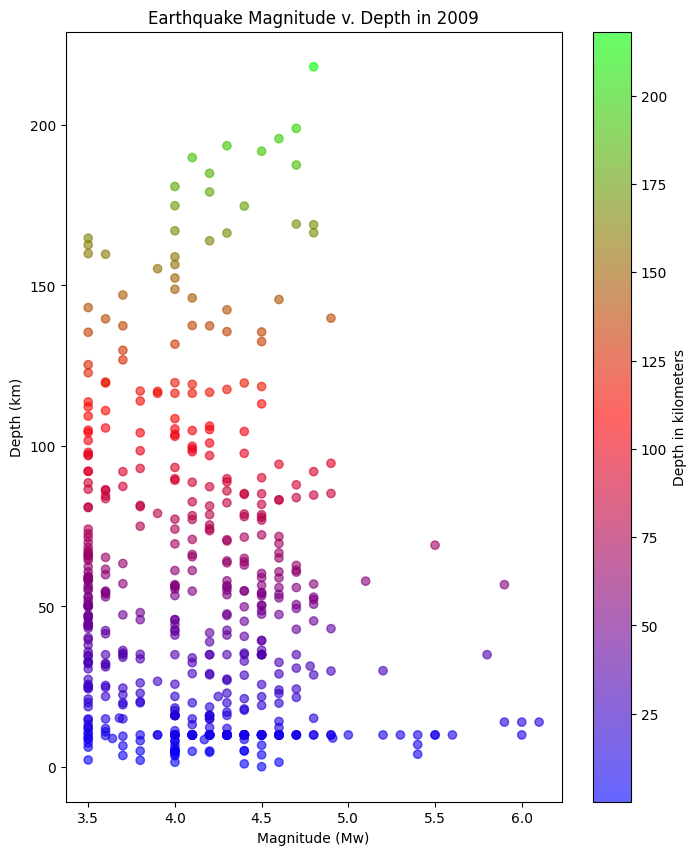

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2010 for depth and mag is: 0.005928788137665624


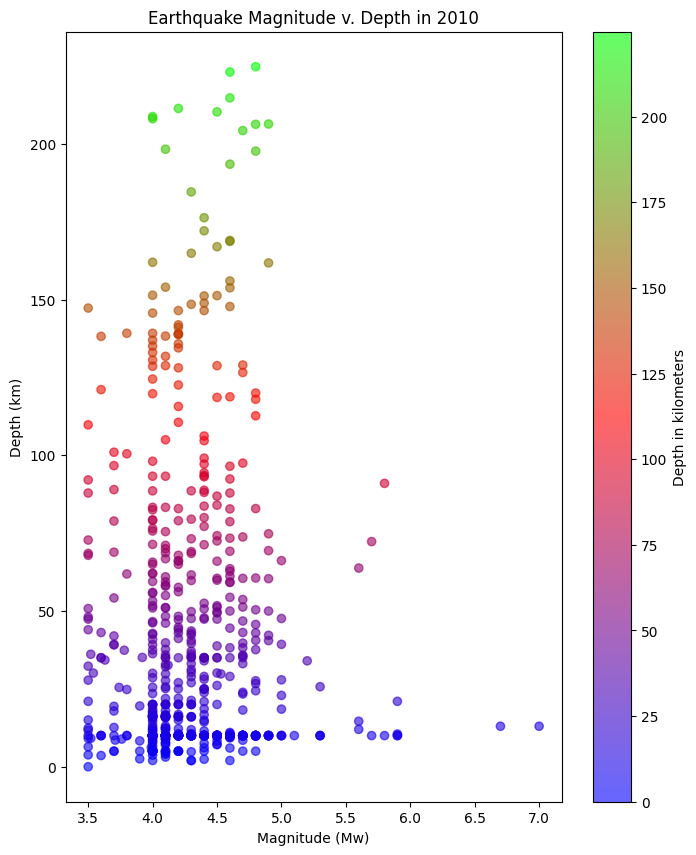

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2011 for depth and mag is: -0.05649241487377523


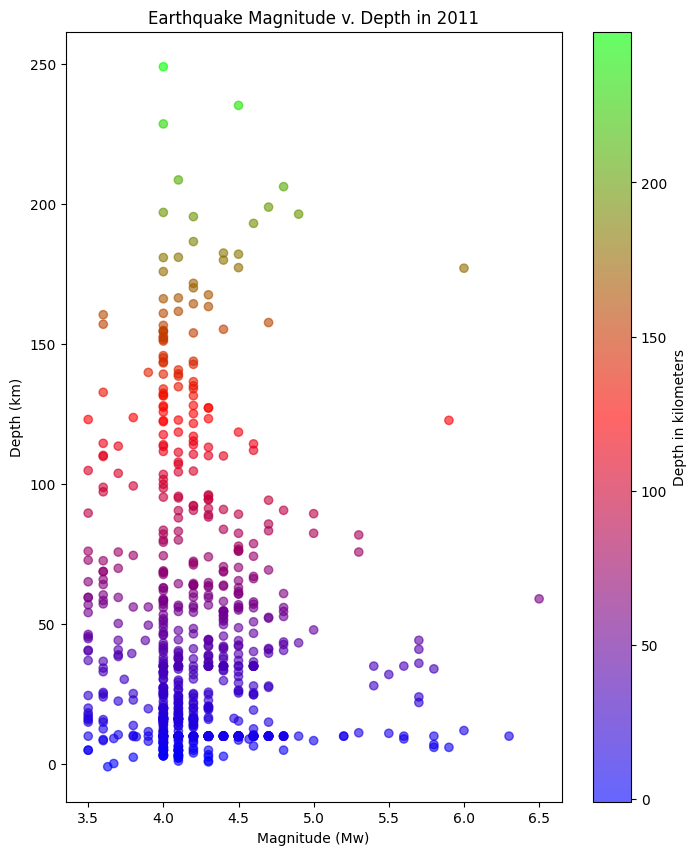

-----------------------------------------------------------------------------------------------------------------------------------------------------------
Pearson r value for 2012 for depth and mag is: -0.09757586758718854


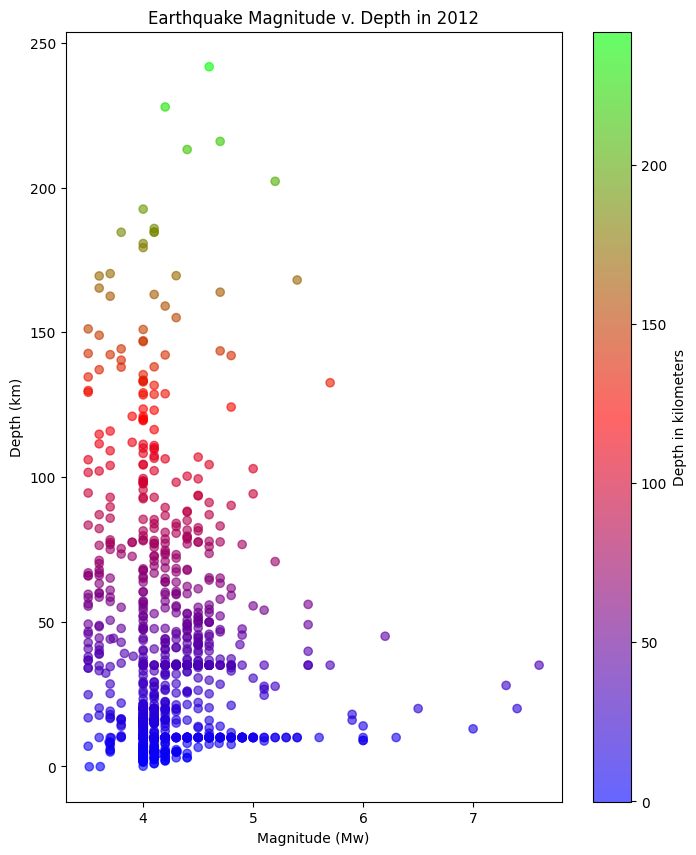

In [17]:
region['year'] = pd.to_datetime(region['date']).dt.year
south_earthquakes = region.groupby(region['year'])
#year = south_earthquakes.get_group(2010)
for x, groupTemp in south_earthquakes:
  year = groupTemp
  rvalue2010 = year['depth'].corr(year['mag'])
  print("-----------------------------------------------------------------------------------------------------------------------------------------------------------")
  print(f"Pearson r value for {x} for depth and mag is: {rvalue2010}")
  plt.figure(figsize=(8, 10))
  plt.scatter(year['mag'], year['depth'], c=year['depth'], cmap='brg', alpha=0.6)
  plt.colorbar(label="Depth in kilometers")
  plt.xlabel("Magnitude (Mw)")
  plt.ylabel("Depth (km)")
  plt.title(f"Earthquake Magnitude v. Depth in {x}")
  plt.show()

There are still a lot of data points, and the R-value is still small, but looking at the graphs makes it much clearer that around a magnitude of 5.5 or higher, there is a negative correlation. The higher the magnitude, the much smaller the depth.

The graphs show more details than before.

1.   Looking over at the highly concentrated years of 2008, 2010, 2011, and 2012, there were 3 years (2008, 2011, and 2012) where depths reached 250km or more.

2.   Looking at all the years, it is also seen that 2010 was the start of seeing fewer earthquakes with a magnitude less than 4. There are many more data points with magnitudes of 4, indicating that earthquakes have become slightly stronger since the 2010s.

3.   2012 has the highest negative correlation rate out of all the years with a -0.0979 percentage. While still weak, this allows us to see a much clearer correlation between an earthquake's magnitude and its depth.

#**Model: Machine Learning, Analysis, and Visualization**


In this phase we perform many modeling techniques, in order to get predictive model of the earthquakes magnitude. We wanted to see if we can predict earthquakes magnitudes based on depth, lat, lon, and year. Later we show how Linear Regession can predict frequency of earthquakes.


###Model on Predicting Magnitude

We are choosing to look at how depth, lat, lon, year because while looking at the correlation over the years of magnitude and depth in the low latitude region of the Northern Hemisphere we saw that there was a weak negative correlation. We wanted to see if all of these features can be used to help predict magnitude.
<br>
We first looked at Linear Regression and see how well the model can predict.

Get the $R^2$ and MSE to compare prediction scores.

In [18]:
#LINEAR
#work if location and/or depth has an impact on magnitude (maybe based on years)


X = region[["depth", "latitude", "longitude", "year"]]
Y = region["mag"]

X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

#Linear Regression
linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print(f"MSE: {linear_mse}")
print(f"R2 score: {linear_r2}")

MSE: 0.17076320051538116
R2 score: 0.07988367722183376


Ask you can see the the R2 score is very low meaning its not predicting right and that is has about 6% variance. The MSE is currently 0.22 percent which isn't super high but 0 means perfect fit so there are ways to possibly improve it too.
<br>
But first let's plot it:

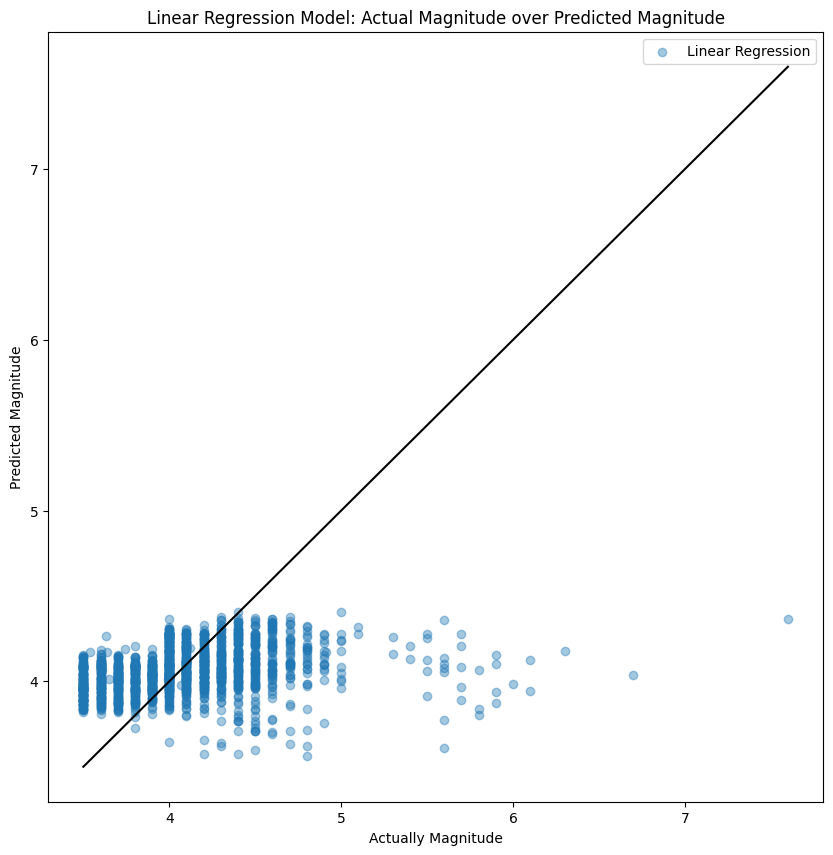

In [19]:
#plot for Linear regression
plt.figure(figsize=(10,10))
plt.scatter(y_test, linear_pred, label="Linear Regression", alpha=0.4)
#how to plot line regression using min max of y_test
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black")
plt.xlabel("Actually Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Linear Regression Model: Actual Magnitude over Predicted Magnitude")
plt.legend()
plt.show()

Linear Regression is not great. It is clear to see that there is not an upward trend and more centered around the 4 magnitude area. It doesn't handle outliers that well.

This model currenly underpredict for large earthquakes magnitudes bigger than 4.5.
<br><br>



There is some more obvious improvements it, was able to predict a lot better than the linear regression.

But we still want to see if we can improve it anymore. Lets Try the Linear Regression model again but adding polynomial features

Version 2: Polynomial Features


In [20]:
from sklearn.preprocessing import PolynomialFeatures

X = region[["depth", "latitude", "longitude", "year"]].copy()
Y = region["mag"]

#center the year so we dont have a large 4 digit value?
X["year"] = X["year"] -  X["year"].min()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

poly = PolynomialFeatures(degree=4, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_predictions = poly_model.predict(X_test_poly)


poly_mse = mean_squared_error(y_test, poly_predictions)
poly_mae = mean_absolute_error(y_test, poly_predictions)
poly_r2 = r2_score(y_test, poly_predictions)

print("Polynomial Regression")
print(f"MSE: {poly_mse}")
print(f"MAE: {poly_mae}")
print(f"R2 score: {poly_r2}")


Polynomial Regression
MSE: 0.11963075127603381
MAE: 0.233209567155194
R2 score: 0.3553985482640394


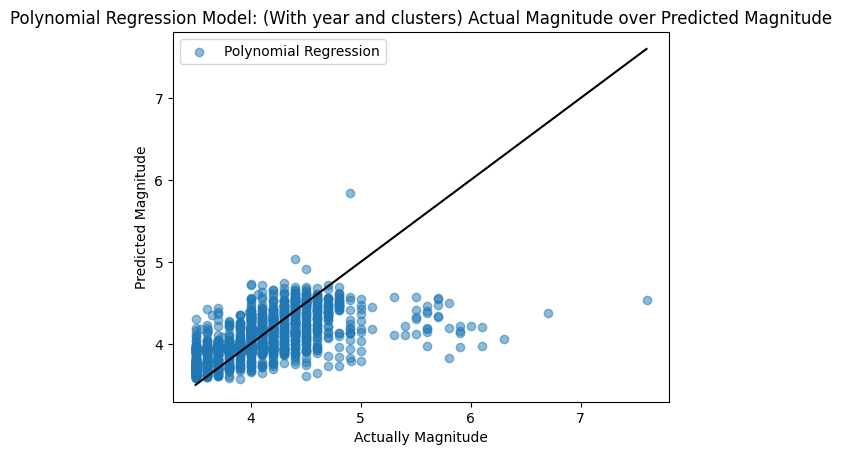

In [21]:
#Polynomial (Linear) Regression version
plt.scatter(y_test, poly_predictions, alpha=0.5, label="Polynomial Regression")
#how to plot line regression using min max of y_test
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black")
plt.xlabel("Actually Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Polynomial Regression Model: (With year and clusters) Actual Magnitude over Predicted Magnitude")
plt.legend()
plt.show()

Version 3: KNN Regression

In [22]:
from scipy.special import kn
#work if location and/or depth has an impact on magnitude (maybe based on years)
#KNN
kn_model = KNeighborsRegressor(n_neighbors=10)
kn_model.fit(X_train, y_train)
kn_predict = kn_model.predict(X_test)


kn_mse = mean_squared_error(y_test, kn_predict)
kn_r2 = r2_score(y_test, kn_predict)
kn_mae = mean_absolute_error(y_test, kn_predict)

print(f"MSE: {kn_mse}")
print(f"MAE: {kn_mae}")
print(f"R2 score: {kn_r2}")

MSE: 0.11352929408385985
MAE: 0.2268483630097645
R2 score: 0.38827477884713746


Lets try using a another model:
**Random Forest model**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

randF_model = RandomForestRegressor(n_estimators=300,random_state=42)

randF_model.fit(X_train, y_train)

randF_predictions = randF_model.predict(X_test)

randF_mse = mean_squared_error(y_test, randF_predictions)
randF_r2 = r2_score(y_test, randF_predictions)

print("\nRandom Forest Regression")
print(f"MSE: {randF_mse}")
print(f"R2 score: {randF_r2}")



Random Forest Regression
MSE: 0.10342032713383112
R2 score: 0.4427445092637248


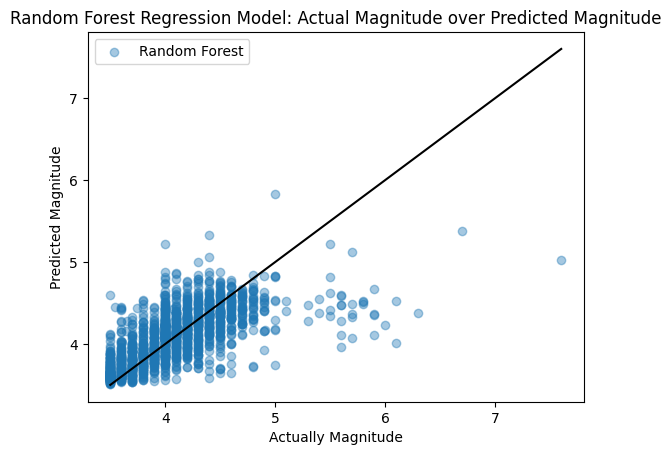

In [24]:
#random forest version
plt.scatter(y_test, randF_predictions, alpha=0.4, label="Random Forest")
#how to plot line regression using min max of y_test
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black")
plt.xlabel("Actually Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Random Forest Regression Model: Actual Magnitude over Predicted Magnitude")
plt.legend()
plt.show()

It way more clear to see that using random forest did improve the predictive model. It is clear to see that there is an upward trend and more centerd around the 4-5 mag area.

Compared to the linear regression it did a lot better but its still isn't great for the low latitude region. In fact random forest regression has made the points predict a larger magnitude than expected.

Both models currently underpredict for large earthquakes magnitudes. Greater than or equal to 6.

Out of all the models Random Forest was the best.

Since Random forest was the best, lets take that model and compare it year by year just like we did for magnitude v depth in Method 3.

Year: 2005
MSE: 0.10863845399305523
R2 score: 0.3040179123568032


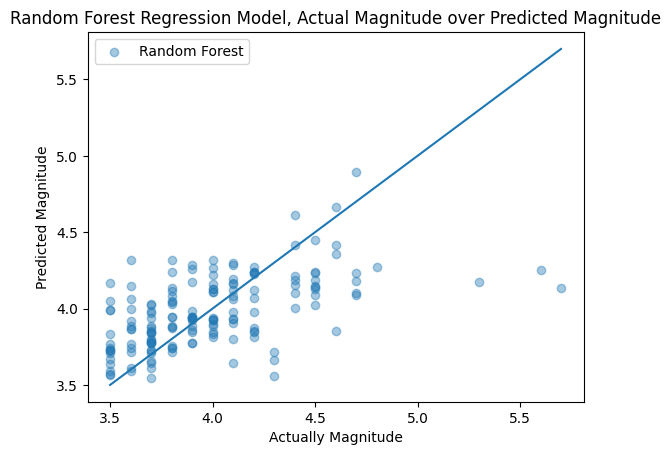

Year: 2006
MSE: 0.0786849106988615
R2 score: 0.269239085680966


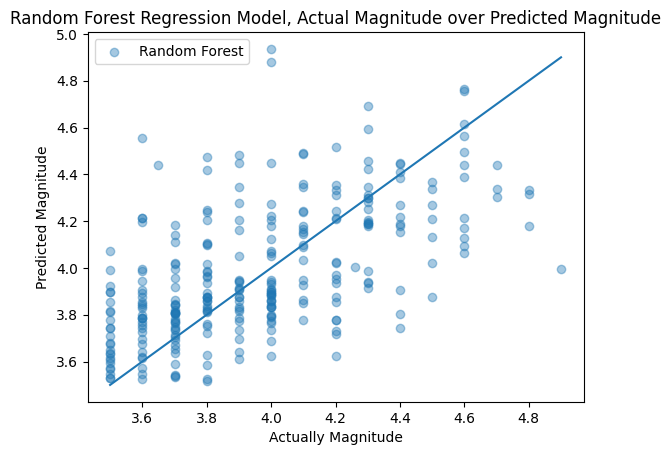

Year: 2007
MSE: 0.10371931557660351
R2 score: 0.13675248435183462


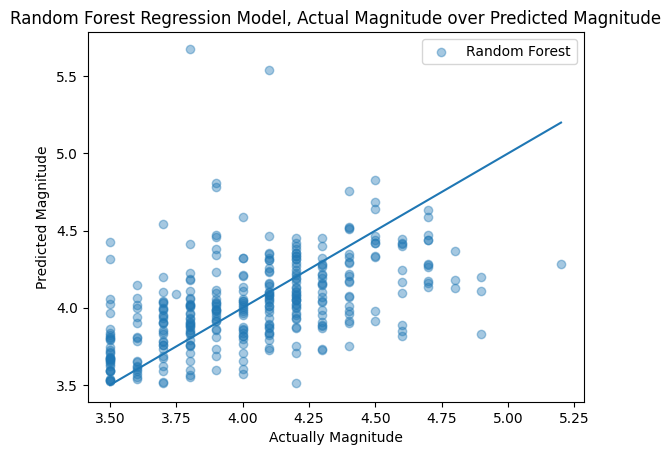

Year: 2008
MSE: 0.06344163802037761
R2 score: 0.37498030924874415


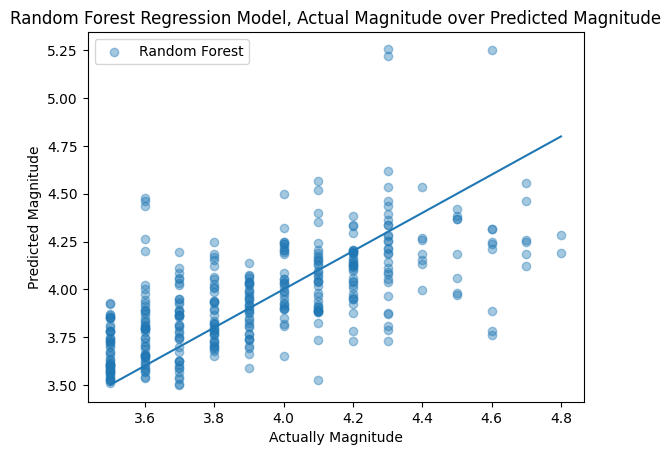

Year: 2009
MSE: 0.16421343329179675
R2 score: 0.49047242812136493


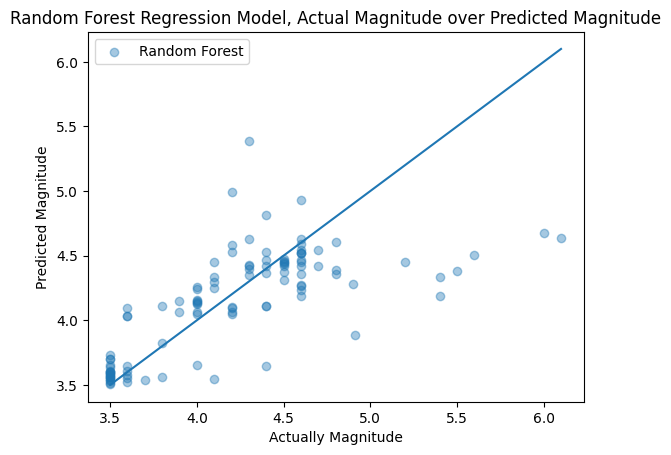

Year: 2010
MSE: 0.1472375203801331
R2 score: 0.17157019229526693


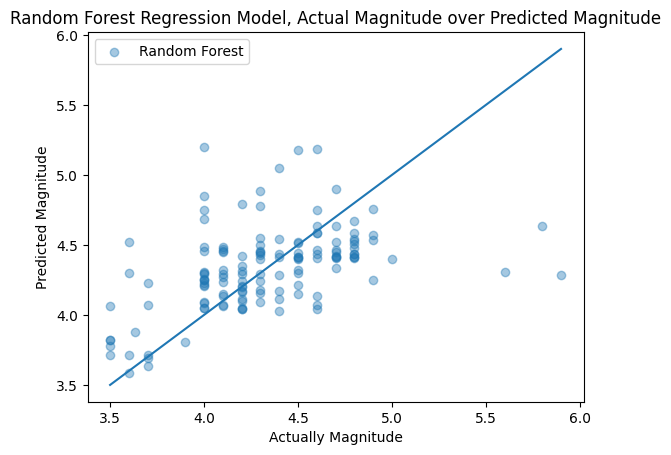

Year: 2011
MSE: 0.12202634647058844
R2 score: 0.2343907117532481


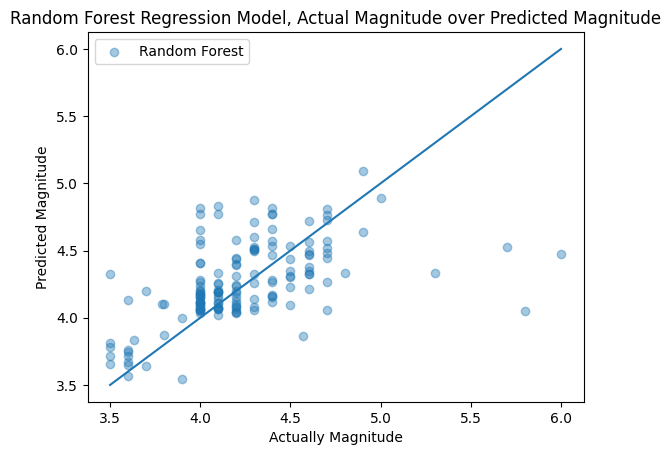

Year: 2012
MSE: 0.1511590149940894
R2 score: -0.14611992621996017


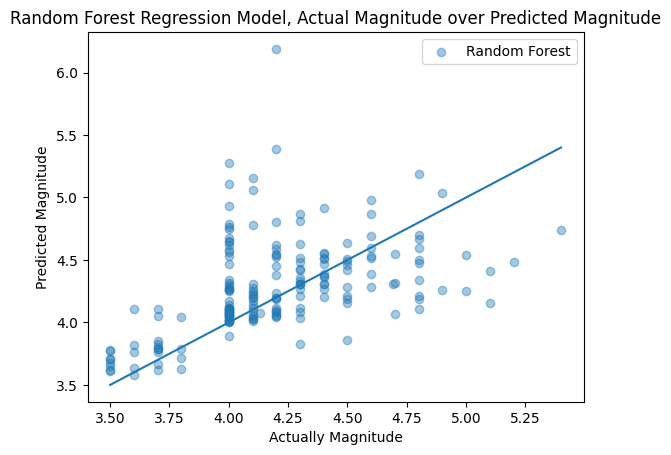

In [25]:
for year, tempGroup in south_earthquakes:
  x=tempGroup[["depth", "longitude"]]
  y=tempGroup["mag"]
  X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
  randFor_model = RandomForestRegressor(n_estimators=300, random_state=42)
  randFor_model.fit(X_train, y_train)
  randFor_predict = randFor_model.predict(X_test)

  print("Year:", year)
  mse = mean_squared_error(y_test, randFor_predict)
  r2 = r2_score(y_test, randFor_predict)
  print(f"MSE: {mse}")
  print(f"R2 score: {r2}")

  plt.scatter(y_test, randFor_predict, alpha=0.4, label="Random Forest")
  #how to plot line regression using min max of y_test
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
  plt.xlabel("Actually Magnitude")
  plt.ylabel("Predicted Magnitude")
  plt.title("Random Forest Regression Model, Actual Magnitude over Predicted Magnitude")
  plt.legend()
  plt.show()




***Anaylsis on Year by Year information***

###Model on Predicting Frequency
Lets try and predict total number of earthquakes over time in the northern hemisphere, but lets focus on the region with the most amount of earthquakes, which is the northern Mid-Atlantic Ridge (based on the information found in Method of Exploration Data Anaylsis). This way we are focus on one region and limits the amount of outliers. The number will either stay the same, which means that there are no new earthquakes or the number will increase, but now we have to ask the question if it increases at the same rate as before.

We have to be carefull when we are splitting the data because we are working with future and past, so we can't split it randomly.

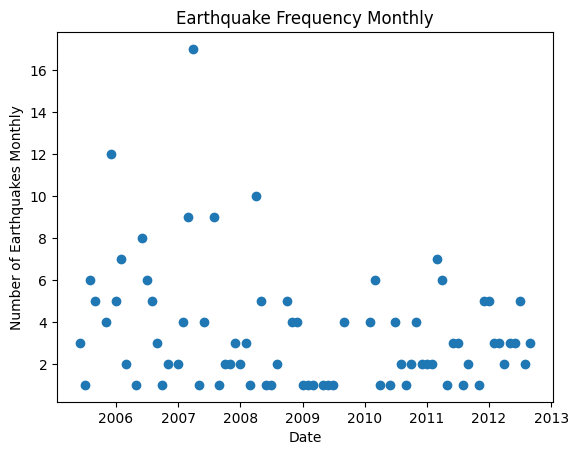

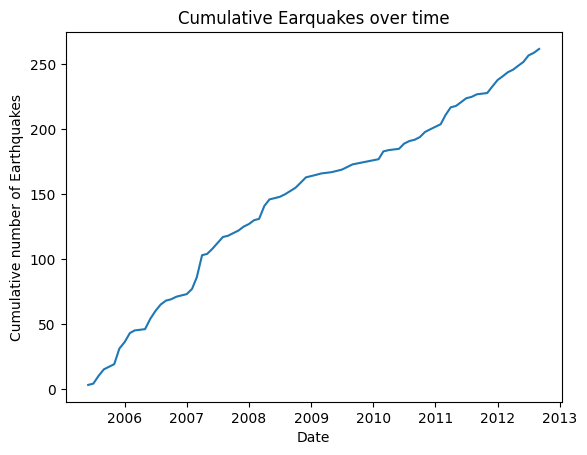

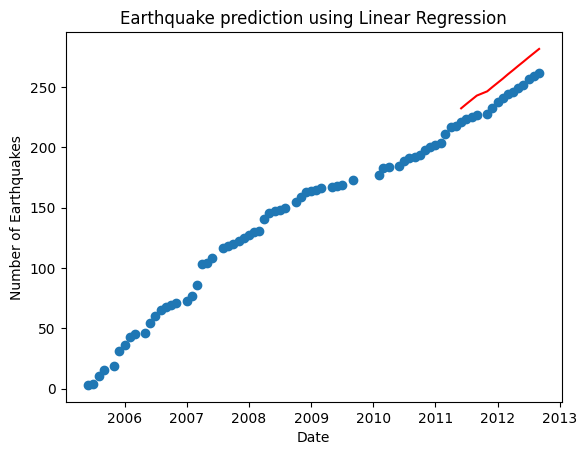

MSE: 284.8544904606615
R2 score: -0.6323415941740231


In [26]:
my_region = earthquakes_df[earthquakes_df['place'] == 'northern Mid-Atlantic Ridge']

region_ml_dataframe = pd.DataFrame()
region_ml_dataframe['year'] = pd.to_datetime(my_region['date']).dt.year
region_ml_dataframe['month'] = pd.to_datetime(my_region['date']).dt.month


#count earthquakes per year per month
region_monthly = region_ml_dataframe.groupby(['year', 'month']).size().reset_index(name='Number of earthquakes')

region_monthly['date'] = pd.to_datetime(
    region_monthly[['year', 'month']].assign(day=1)
)


#i need to create a continuous time variable
region_monthly['continuous_time'] = range(len(region_monthly))
#cumsum is the cumulative sum over the years
region_monthly['earthquake_count'] = region_monthly['Number of earthquakes'].cumsum()

#see the plot and see if we can see a trend over the years
plt.scatter(region_monthly['date'], region_monthly['Number of earthquakes'])
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes Monthly')
plt.title('Earthquake Frequency Monthly')
plt.show()

plt.plot(region_monthly['date'], region_monthly['earthquake_count'])
plt.xlabel('Date')
plt.ylabel('Cumulative number of Earthquakes')
plt.title('Cumulative Earquakes over time')
plt.show()

#it needs to have 2 [[]] because it needs to be a 2D array for the model to work,
#if it was just one [] it would be a 1D array and the model would not work
X = region_monthly[['continuous_time']]
Y = region_monthly['earthquake_count']


#20% will be test, 80% will be train
where_to_split_data = int(len(X) * 0.8)
X_train = X[: where_to_split_data]
X_test = X[where_to_split_data :]

Y_train = Y[: where_to_split_data]
Y_test = Y[where_to_split_data :]




#Linear Regression
model = LinearRegression()
model.fit(X_train, Y_train)
model_pred = model.predict(X_test)


plt.scatter(region_monthly['date'], region_monthly['earthquake_count'],
            label='Actual earthquakes')

plt.plot(region_monthly['date'][where_to_split_data:], model_pred, color='red',
         label='Prediction Linear Regression')

plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Earthquake prediction using Linear Regression')
plt.show()


model_mse = mean_squared_error(Y_test, model_pred)
model_r2 = r2_score(Y_test, model_pred)

print(f"MSE: {model_mse}")
print(f"R2 score: {model_r2}")



From the results we see that in our prediction we are off by about 20 earthquakes. We can clearly see on the graphs that the line does continue to increase, but around 2011 something happens and there are less earthquakes happening.
Its possible that the overprediction of earthquakes could be from the spike of earthquakes recorded in 2010.
<br>
Because the graph has somewhat of a curve we will try to use the polynomial model to try to make another prediction.




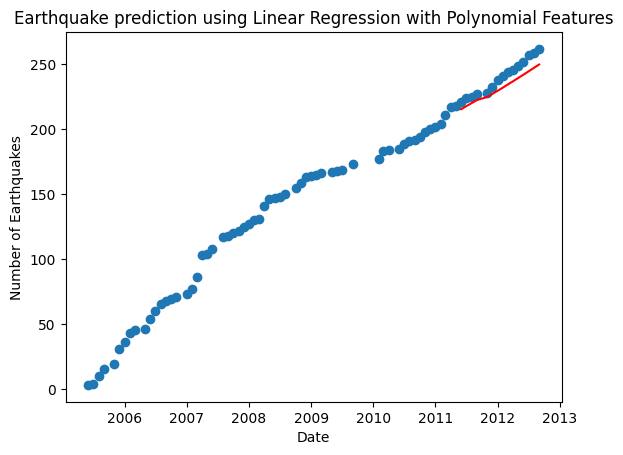

MSE: 72.42371824312487
R2 score: 0.5849802209478633


In [27]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, Y_train)
model_pred = model.predict(X_test_poly)

plt.scatter(region_monthly['date'], region_monthly['earthquake_count'],
            label='Actual earthquakes')

plt.plot(region_monthly['date'][where_to_split_data:], model_pred, color='red',
         label='Prediction Linear Regression')

plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Earthquake prediction using Linear Regression with Polynomial Features')
plt.show()

model_mse = mean_squared_error(Y_test, model_pred)
model_r2 = r2_score(Y_test, model_pred)

print(f"MSE: {model_mse}")
print(f"R2 score: {model_r2}")

The polynomial model is performing even worse than the linear model. Now our prediction is off by more than 37 earthquakes.

The Linear model predicts that it has 20 earthquakes above the actual number and the Polynomial model predicts that it has 37 earthquakes less than the actual number. Based only on time alone we cannot predict the cumulative amount of earthquakes during our dates.


#**Insights & Conclusions**


Overall our question about finding by looking at features such as depth, latitude, longitude, and year, we could predict an earthquake's magnitude.

Even though it looks like magnitude looks like its increasing over the year it can be from fact that the earthquake detector instruaments have gotten better and are more prone to the slightly interference. (cite source)

We wanted to find out if magnitude was affected by factors of frequency, lat, lon, depth, and year. We found that that earthquakes are more frequent in the low latitudes in the Northern hempisphere. So we decided to focus on that region when looking at magnitude. We found that there is very small correlation between magnitude and depth, it slightly negative showing that the bigger the earthquake the smaller the depth. We use this information to help move forward in predicting magnitude.

Our different model predictions showed that even though low we focused in areas of low latitude